# Evaluating AI Coding Agents on Ontology Curation — Exploratory Analysis

*Standalone analysis notebook for the paper.* The working document where
we explore the evaluation results and develop the findings. Detailed and
partly redundant with `01_scores_overview` by design — read this one
end-to-end.

## What we measure

We replay **real, merged pull requests** from four OBO ontologies
(Gene Ontology, Mondo, Uberon, Cell Ontology). For each curated
issue→PR case an agent is given the *issue* and the repo at the PR's
base commit and must produce a PR. **Two independent reviewing agents**
(`claude` = Claude Opus 4.7, `codex`) then read the issue, the human
"gold" PR, and the agent's PR and assign an outcome.

**Why reviewer scores, not metadiff F1.** F1 (token overlap vs the
single gold PR) is *too noisy*: ~half the mined cases have a flawed gold
(resolved across companion PRs, leaked into the eval base, or the linked
PR doesn't resolve the issue), and serialization artefacts swing F1 even
on clean cases. We use the **reviewer outcome verdict** as the primary
measure:

> `success` → 1.0  `partial_success` → 0.5  `failure`/`no_output` → 0.0

with the **consensus** = mean of the two reviewers when both saw a PR.
§3 quantifies F1's noise; §4 validates the reviewer score before use.


In [1]:
import os
while not os.path.exists('analysis/scores.tsv'):
    os.chdir('..')
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns, re, yaml
from pathlib import Path
from IPython.display import display, Markdown
from ai4c_scribe.analysis import (
    load_scores, load_reviews, attach_case_quality, pair_reviewers,
    cohen_kappa, reviewer_case_scores, paired_test, significance_summary,
    failure_mode_counts,
)
sns.set_theme(style='whitegrid', font_scale=1.05)
pd.set_option('display.precision', 3)

def show(df, grad=None, pct=None, caption=None, fmt=None, hide_index=False):
    """Render a DataFrame as a styled HTML table."""
    s = df.style
    f = {}
    if fmt: f.update(fmt)
    if pct: f.update({c: '{:.0%}' for c in pct})
    if f: s = s.format(f, na_rep='—')
    if grad: s = s.background_gradient(subset=grad, cmap='RdYlGn', vmin=0, vmax=1)
    if caption: s = s.set_caption(caption).set_table_styles(
        [{'selector':'caption','props':[('font-weight','bold'),('font-size','1.05em'),('text-align','left'),('padding','4px')]}])
    if hide_index: s = s.hide(axis='index')
    display(s)

scores = attach_case_quality(load_scores('analysis/scores.tsv'))
scores['agent'] = pd.read_csv('analysis/scores.tsv', sep='\t')['agent'].values  # canonical
reviews = load_reviews()
rcs = reviewer_case_scores(reviews, scores)
clear = rcs[rcs.case_quality != 'poor'].copy()
std = clear[clear.agent.str.startswith('std_')].copy()
STD = ['std_claude_op47','std_claude_son45','std_claude_hai45','std_codex_g55',
       'std_codex_g54','std_opencode_g55','std_opencode_g54','std_copilot_son45',
       'std_opencode_kimi','std_opencode_gem4']
display(Markdown(
    f"**{scores.case.nunique()} cases**, **{len(scores)} scored runs**, "
    f"**{len(reviews)} review files** — `reviewer_case_scores`: {len(rcs)} "
    f"(agent, case) rows, **{len(clear)} on clear cases** (analysis universe)."))


**149 cases**, **1662 scored runs**, **3357 review files** — `reviewer_case_scores`: 1186 (agent, case) rows, **621 on clear cases** (analysis universe).

## 1. The benchmark: cases

Cases are mined issue→PR pairs, curated with task type, difficulty,
scope, and a **quality flag**. A large fraction of *real* merged PRs are
unsuitable as a single-gold target — the central methodological finding.

case_quality,good,ok,poor,total,% poor
ontology,,,,,
cell-ontology,3,12,22,37,59%
go-ontology,20,3,13,36,36%
mondo,5,13,19,37,51%
uberon,7,13,19,39,49%


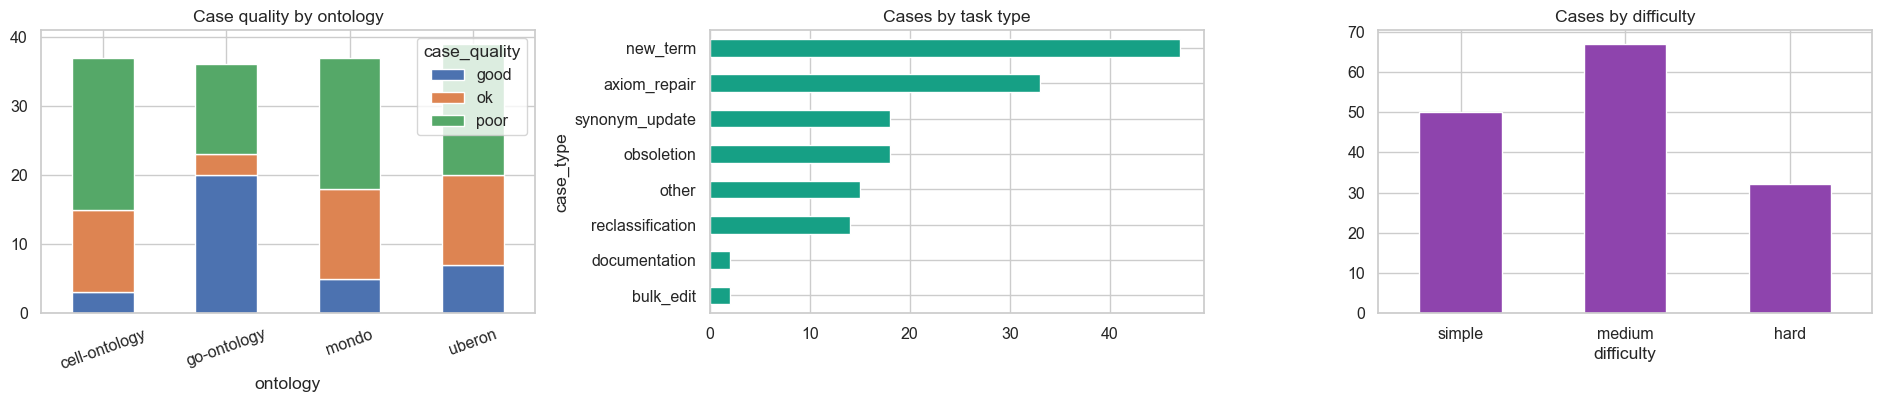

➡️ **49%** of curated cases are unusable for automatic scoring and are excluded from every comparison.

In [2]:
cases = scores.drop_duplicates('case')
q = (cases.groupby(['ontology','case_quality']).size().unstack(fill_value=0))
q['total'] = q.sum(axis=1); q['% poor'] = (q.get('poor',0)/q['total'])
show(q, pct=['% poor'], caption='Cases by ontology × quality')

fig, ax = plt.subplots(1, 3, figsize=(19,4.2))
cases.groupby(['ontology','case_quality']).size().unstack(fill_value=0).plot.bar(
    stacked=True, ax=ax[0]); ax[0].set_title('Case quality by ontology'); ax[0].tick_params(axis='x',rotation=20)
cases.groupby('case_type').size().sort_values().plot.barh(ax=ax[1], color='#16a085'); ax[1].set_title('Cases by task type')
cases.groupby('difficulty').size().reindex(['simple','medium','hard']).plot.bar(
    ax=ax[2], color='#8e44ad'); ax[2].set_title('Cases by difficulty'); ax[2].tick_params(axis='x',rotation=0)
plt.tight_layout(); plt.savefig('analysis/notebooks/fig_pp_cases.png',dpi=150); plt.show()
display(Markdown(f"➡️ **{(cases.case_quality=='poor').mean():.0%}** of curated cases are "
                 "unusable for automatic scoring and are excluded from every comparison."))


### 1a. What a case looks like

The agent sees only the *issue* and the base repo. Three real cases — a
clean one and two flagged `poor` — to make the task and the curation
concrete:

In [3]:
def case_md(issue):
    for f in Path('analysis').glob('*/cases/*/METADATA.md'):
        t=f.read_text()
        if re.search(rf'^issue_number:\s*{issue}\b', t, re.M):
            fm=yaml.safe_load(t[3:t.index('---',3)])
            fc=fm.get('files_changed') or []
            edits=", ".join(f"`{c.get('path','?')}` (+{c.get('additions',0)}/-{c.get('deletions',0)})" for c in fc[:3])
            cq=fm.get('case_quality','unflagged'); rsn=fm.get('case_quality_reason')
            badge = {'poor':'🔴','ok':'🟡','good':'🟢'}.get(cq,'⚪')
            return (f"**{f.parts[1]} · issue #{fm.get('issue_number')}** → gold PR "
                    f"#{fm.get('pr_number')}  {badge} `{cq}`"
                    + (f" — *{rsn}*" if rsn else "") + "\n\n"
                    f"> **{fm.get('issue_title')}**  \n"
                    f"> task: `{fm.get('task_type')}` · difficulty: `{fm.get('difficulty')}` "
                    f"· scope: `{fm.get('scope')}`  \n"
                    f"> gold edits: {edits}")
    return f"(issue {issue} not found)"
display(Markdown("\n\n---\n\n".join(case_md(i) for i in ['3559','31670','5726'])))


**cell-ontology · issue #3559** → gold PR #3564  🟡 `ok` — *metadiff_underrepresents_substance*

> **[Synonym] abbreviations like PBMC**  
> task: `synonym_update` · difficulty: `simple` · scope: `multi_term`  
> gold edits: `src/ontology/cl-edit.owl` (+3/-0)

---

**go-ontology · issue #31670** → gold PR #31676  🔴 `poor` — *gold_pr_is_partial*

> **Taxon constraint: please add for GO:0070478 and similar terms**  
> task: `new_term` · difficulty: `hard` · scope: `multi_term`  
> gold edits: `src/taxon_constraints/only_in_taxon.tsv` (+4/-1)

---

**mondo · issue #5726** → gold PR #10155  🔴 `poor` — *gold_leakage_base_contamination*

> **Add non-human animal diseases from VeNom**  
> task: `new_term` · difficulty: `hard` · scope: `structural_refactor`  
> gold edits: `src/ontology/mondo-edit.obo` (+9006/-0)

## 2. The agents

An **agent** = (harness/runtime) × (model) × (config). The harness is
the coding CLI driving the model (Claude Code, Codex, OpenCode, Copilot
CLI, Gemini CLI). This factorisation lets us ask: *does the model
matter?* and *does the harness matter?*

In [4]:
tbl = (std.groupby('agent')
       .agg(model=('model','first'), runtime=('runtime','first'),
            n_cases=('case','nunique'), mean_rscore=('rscore','mean'))
       .reindex(STD).dropna(how='all').sort_values('mean_rscore', ascending=False))
show(tbl.reset_index(), grad=['mean_rscore'], fmt={'mean_rscore':'{:.3f}'},
     hide_index=True, caption='Standard agents (clear cases), ranked by reviewer score')


agent,model,runtime,n_cases,mean_rscore
std_claude_op47,claude-opus-4.7,claude,75,0.820
std_codex_g55,gpt-5.5,codex,56,0.750
std_opencode_g55,gpt-5.5,opencode,72,0.742
std_claude_son45,claude-sonnet-4.5,claude,76,0.738
std_copilot_son45,claude-sonnet-4.5,copilot,39,0.731
std_opencode_gem4,gemma-4-31b,opencode,32,0.703
std_codex_g54,gpt-5.4,codex,73,0.702
std_opencode_g54,gpt-5.4,opencode,71,0.697
std_opencode_kimi,kimi-k2.6,opencode,49,0.696
std_claude_hai45,claude-haiku-4.5,claude,76,0.605


## 3. Why not F1 — quantifying the noise

If F1 tracked quality we would not need reviewers. Within a *single*
reviewer verdict F1 is spread across the whole range; the two correlate
only weakly.

Clear-case PRs with both signals: **n=835** · Pearson r = **0.63** · Spearman = **0.66** (weak — F1 is not a good proxy for quality).

consensus_score,n,mean_F1,std_F1,median_F1
0.00,28,0.211,0.220,0.125
0.25,17,0.212,0.222,0.167
0.50,373,0.500,0.291,0.500
0.75,59,0.709,0.160,0.706
1.00,358,0.855,0.196,0.922


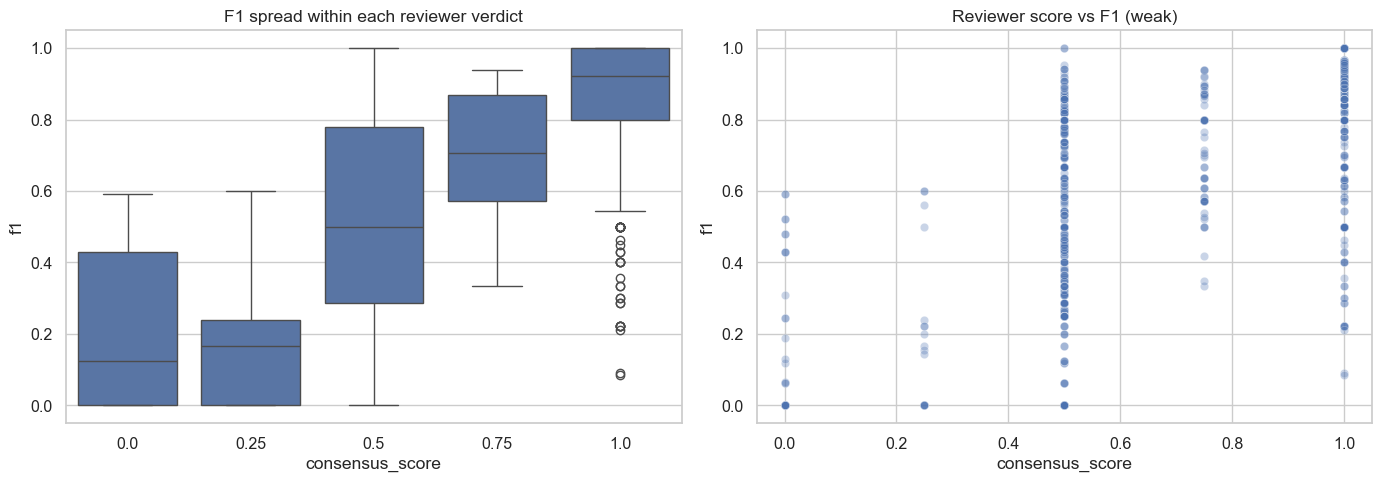

In [5]:
m = pair_reviewers(reviews).copy()
m['eval_repo_pr']=pd.to_numeric(m.eval_repo_pr,errors='coerce')
sj=scores.copy(); sj['eval_repo_pr']=pd.to_numeric(sj.eval_repo_pr,errors='coerce')
meta=sj.drop_duplicates(['ontology','eval_repo_pr']).set_index(['ontology','eval_repo_pr'])[['f1','case_quality']]
ix=m.set_index(['ontology','eval_repo_pr']).index
m['f1']=pd.to_numeric(ix.map(meta['f1']),errors='coerce'); m['cq']=ix.map(meta['case_quality'])
mc=m[m.cq!='poor'].dropna(subset=['f1','consensus_score'])
display(Markdown(
    f"Clear-case PRs with both signals: **n={len(mc)}** · "
    f"Pearson r = **{mc.consensus_score.corr(mc.f1):.2f}** · "
    f"Spearman = **{mc.consensus_score.corr(mc.f1, method='spearman'):.2f}** "
    "(weak — F1 is not a good proxy for quality)."))
g=mc.groupby('consensus_score')['f1'].agg(n='count', mean_F1='mean', std_F1='std', median_F1='median')
show(g.reset_index(), grad=['mean_F1'], hide_index=True,
     fmt={'consensus_score':'{:.2f}','mean_F1':'{:.3f}','std_F1':'{:.3f}','median_F1':'{:.3f}'},
     caption='F1 spread WITHIN each reviewer consensus level')
fig,ax=plt.subplots(1,2,figsize=(14,5))
sns.boxplot(data=mc,x='consensus_score',y='f1',ax=ax[0]); ax[0].set_title('F1 spread within each reviewer verdict')
sns.scatterplot(data=mc.sample(min(len(mc),1200),random_state=1),x='consensus_score',y='f1',alpha=.3,ax=ax[1])
ax[1].set_title('Reviewer score vs F1 (weak)')
plt.tight_layout(); plt.savefig('analysis/notebooks/fig_pp_f1noise.png',dpi=150); plt.show()


## 4. Is the reviewer score trustworthy? (inter-annotator agreement)

Before ranking agents we check the two reviewing agents agree.
*Paired* = the same eval PR independently reviewed by both.

paired n,exact outcome agree,3-pt score agree,mean |Δ score|,Cohen's κ,weighted κ,claude mean,codex mean
761,0.717,0.723,0.147,0.518,0.559,0.682,0.564


ontology,n,exact_agree,kappa
cell-ontology,15,1.000,1.000
go-ontology,376,0.864,0.755
mondo,370,0.557,0.240


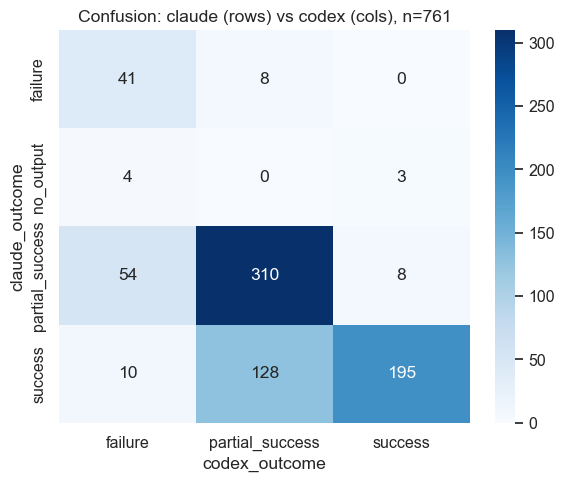

In [6]:
p=pair_reviewers(reviews); both=p.dropna(subset=['claude_score','codex_score']).copy(); n=len(both)
kpi=pd.DataFrame([{
 'paired n':n,
 'exact outcome agree': (both.claude_outcome==both.codex_outcome).mean(),
 '3-pt score agree': (both.claude_score==both.codex_score).mean(),
 'mean |Δ score|': (both.claude_score-both.codex_score).abs().mean(),
 "Cohen's κ": cohen_kappa(both.claude_outcome,both.codex_outcome),
 'weighted κ': cohen_kappa(both.claude_score,both.codex_score,weights='linear'),
 'claude mean': both.claude_score.mean(), 'codex mean': both.codex_score.mean()}])
show(kpi, hide_index=True, fmt={c:'{:.3f}' for c in kpi.columns if c!='paired n'},
     caption='Inter-annotator agreement (claude vs codex)')
byo=both.groupby('ontology').apply(lambda g: pd.Series({'n':len(g),
     'exact_agree':(g.claude_outcome==g.codex_outcome).mean(),
     'kappa':cohen_kappa(g.claude_outcome,g.codex_outcome) if len(g)>3 else np.nan})).reset_index()
show(byo, grad=['exact_agree','kappa'], hide_index=True,
     fmt={'n':'{:.0f}','exact_agree':'{:.3f}','kappa':'{:.3f}'}, caption='Agreement by ontology')
fig,ax=plt.subplots(figsize=(6,5))
sns.heatmap(pd.crosstab(both.claude_outcome,both.codex_outcome),annot=True,fmt='d',cmap='Blues',ax=ax)
ax.set_title(f'Confusion: claude (rows) vs codex (cols), n={n}')
plt.tight_layout(); plt.savefig('analysis/notebooks/fig_pp_iaa.png',dpi=150); plt.show()


**Interpretation.** Moderate–substantial agreement (κ≈0.5 nominal,
higher weighted); disagreement concentrates on the soft
`partial`↔`success` boundary, not hard flips, and `codex` is the harsher
reviewer. Strong on GO, weak on Mondo — Mondo numbers are flagged where
used. The **consensus** cancels per-reviewer harshness.

## 5. Worked examples — what the reviewers actually wrote

Grounding the 0 / 0.5 / 1 scale in real reviewer prose.

In [7]:
def excerpt(ontology, eval_pr, reviewer, n=550):
    for f in sorted(Path(f'analysis/{ontology}/results/reviews').glob(f'pr{eval_pr}-*{reviewer}*-complete.md')):
        b=f.read_text(); b=b[b.index('---',3)+3:].strip()
        return f.name, b[:n].strip()
    return None,None
pp=pair_reviewers(reviews); pp['eval_repo_pr']=pd.to_numeric(pp.eval_repo_pr,errors='coerce')
sj2=scores.copy(); sj2['eval_repo_pr']=pd.to_numeric(sj2.eval_repo_pr,errors='coerce')
blocks=[]; shown=set()
for tgt,label,emoji in [(1.0,'SUCCESS','🟢'),(0.5,'PARTIAL','🟡'),(0.0,'FAILURE','🔴')]:
    row=std[(std.rscore==tgt)&(~std.case.isin(shown))].sort_values('agent').head(1)
    if row.empty: continue
    r=row.iloc[0]; shown.add(r['case'])
    cand=sj2[(sj2.agent==r['agent'])&(sj2.case==r['case'])].dropna(subset=['eval_repo_pr'])
    if cand.empty: continue
    epr=int(cand.iloc[0]['eval_repo_pr']); ont=cand.iloc[0]['ontology']
    md_=[f"### {emoji} {label} — `{r['agent']}` on `{r['case']}` ({r['case_type']}, {r['difficulty']}) · reviewer score {tgt}"]
    for rev in ('claude','codex'):
        fn,ex=excerpt(ont,epr,rev)
        if ex: md_.append(f"**{rev} review** ({fn}):\n\n> "+ex.replace(chr(10),'\n> '))
    blocks.append("\n\n".join(md_))
display(Markdown("\n\n---\n\n".join(blocks)))


### 🟢 SUCCESS — `std_claude_hai45` on `cel#3382` (axiom_repair, simple) · reviewer score 1.0

**claude review** (pr96-claude-complete.md):

> ## Summary
> 
> claude-haiku-4.5 (claude) produced the exactly correct fix for issue #3382:
> replacing `BFO_0000051` (has_part) with `RO_0002104` (has_plasma_membrane_part)
> for `PR_000001207` (CXCR3) in the `EquivalentClasses` axiom of CL:0001041
> (CD8-positive, CXCR3-positive, alpha-beta regulatory T cell). The agent's diff
> is byte-identical to the merged gold human PR #3440 (blob `515bbaa`). The
> F1=1.0 is genuine and accurately represents quality — this is the literal
> minimal one-line substitution the issue requested, independently reproduced
> (not

**codex review** (pr96-codex-complete.md):

> ## Summary
> 
> The attempt is exactly correct. It replaces `BFO_0000051` with `RO_0002104` for
> the CXCR3 plasma-membrane marker restriction in `CL_0001041`.
> 
> This matches the gold PR line-for-line.
> 
> ## Strengths
> 
> The edit is minimal, scoped, and uses the precise relation requested by the
> issue. No extra annotations or formatting changes were introduced.
> 
> ## Issues
> 
> No issues found.

---

### 🟡 PARTIAL — `std_claude_hai45` on `cel#3243` (axiom_repair, medium) · reviewer score 0.5

**claude review** (pr89-claude-complete.md):

> ## Summary
> 
> The agent did the surface portion of issue #3243 well — renamed CL_0000135 to "circulating fibrocyte", installed the issue's literature definition with the right PMID set, and added the "monocyte-derived fibrocyte" narrow synonym — but it **did not update the logical definition at all**, leaving the obsolete `EquivalentClasses(... GO_0002495 ... GO_0045766)` and the now-incorrect `develops_from some CL_0000057` (fibroblast) axioms in place. Because the issue's central ask was a *logical* def revision (the title is "[Text and logical

**codex review** (pr89-codex-complete.md):

> ## Summary
> 
> The attempt performs the surface text changes but misses the central logical
> definition repair. It renames fibrocyte to circulating fibrocyte, replaces the
> definition, and adds the monocyte-derived fibrocyte synonym, but leaves the old
> `EquivalentClasses` axiom and the stale `develops_from some CL_0000057`
> fibroblast origin in place.
> 
> Because the issue explicitly asked for both textual and logical definition
> changes, this is only a partial success.
> 
> ## Strengths
> 
> The revised label and definition are close to the accepted PR, with ap

---

### 🔴 FAILURE — `std_claude_hai45` on `cel#3333` (axiom_repair, simple) · reviewer score 0.0

**claude review** (pr145-claude-complete.md):

> ## Summary
> 
> Identical outcome to attempt #202 (same `17912f0` blob): the agent removed the
> six genuinely redundant `oboInOwl:*` synonym/xref labels (correct) but also
> deleted the `rdfs:label` axioms for `obo:IAO_0000028` ("symbol"),
> `oboInOwl:SubsetProperty`, `oboInOwl:consider`, `oboInOwl:inSubset`, and
> `rdfs:seeAlso`, none of which is labeled in `merged_import.owl`. That is
> information loss, not redundant cleanup. F1=0.522 accurately represents
> genuinely worse work; this is a correctness error, not a metadiff artifact.
> 
> ## Strengths
> 
> - Correc

**codex review** (pr145-codex-complete.md):

> ## Summary
> 
> This attempt removes the six redundant `oboInOwl:*` synonym/xref labels that the
> human PR removed, but it also deletes five labels that should have stayed:
> `obo:IAO_0000028`, `oboInOwl:SubsetProperty`, `oboInOwl:consider`,
> `oboInOwl:inSubset`, and `rdfs:seeAlso`.
> 
> Those extra deletions are not harmless cleanup. The issue was specifically to
> remove labels already supplied by `merged_import`; the extra labels are not the
> same redundant imported-label pattern. The result is an over-broad cleanup that
> loses information and leaves dangli

## 6. Exploratory questions

Paired tests on the cases two agents *share* (one mean reviewer score
per agent per case), clear cases only. We report mean difference,
paired-t / Wilcoxon p, Cohen's d, n shared. *Exploratory — not
multiplicity-corrected.*

### Q1 · Does the model matter? (Claude Code: Opus vs Sonnet vs Haiku)

A,B,n,mean A,mean B,Δ (B−A),t-p,wilcoxon-p,Cohen d,sig
std_claude_op47,std_claude_son45,75,0.820,0.741,-0.079,0.024,0.035,-0.27,✓
std_claude_son45,std_claude_hai45,76,0.738,0.605,-0.133,1.8e-05,6.4e-05,-0.52,✓
std_claude_op47,std_claude_hai45,75,0.820,0.607,-0.213,4.9e-08,1.6e-06,-0.70,✓


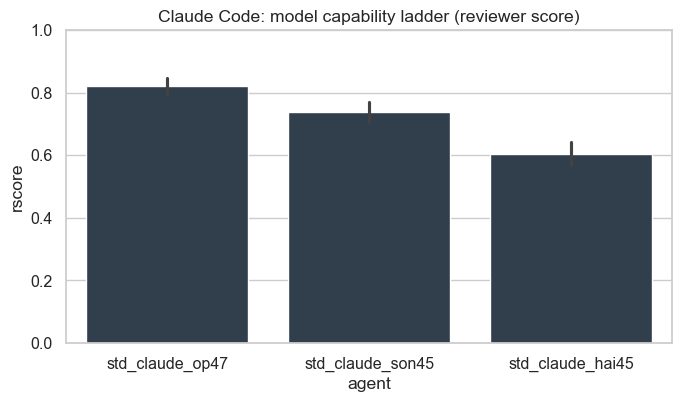

In [8]:
def h2h_rows(pairs, df=std):
    out=[]
    for a,b in pairs:
        r=paired_test(df,a,b,score_col='rscore')
        if not r: continue
        out.append({'A':a,'B':b,'n':r['n_shared'],'mean A':r['mean_a'],'mean B':r['mean_b'],
                    'Δ (B−A)':r['mean_b']-r['mean_a'],'t-p':r['p_value_ttest'],
                    'wilcoxon-p':r['p_value_wilcoxon'],"Cohen d":r['cohens_d'],
                    'sig':'✓' if r['significant'] else ''})
    return pd.DataFrame(out)
def show_h2h(df, cap):
    sty=(df.style.format({'mean A':'{:.3f}','mean B':'{:.3f}','Δ (B−A)':'{:+.3f}',
            't-p':'{:.2g}','wilcoxon-p':'{:.2g}','Cohen d':'{:+.2f}','n':'{:.0f}'}, na_rep='—')
         .background_gradient(subset=['Δ (B−A)'], cmap='RdBu', vmin=-.3, vmax=.3)
         .apply(lambda s:['background-color:#d4efdf' if v=='✓' else '' for v in s], subset=['sig'])
         .set_caption(cap).hide(axis='index')
         .set_table_styles([{'selector':'caption','props':[('font-weight','bold'),('text-align','left'),('padding','4px')]}]))
    display(sty)
show_h2h(h2h_rows([('std_claude_op47','std_claude_son45'),
                   ('std_claude_son45','std_claude_hai45'),
                   ('std_claude_op47','std_claude_hai45')]),
         'Q1 — Claude Code model ladder')
sub=std[std.agent.isin(['std_claude_op47','std_claude_son45','std_claude_hai45'])]
fig,ax=plt.subplots(figsize=(7,4.2))
sns.barplot(data=sub,x='agent',y='rscore',
            order=['std_claude_op47','std_claude_son45','std_claude_hai45'],
            errorbar='se',ax=ax,color='#2c3e50'); ax.set_ylim(0,1)
ax.set_title('Claude Code: model capability ladder (reviewer score)')
plt.tight_layout(); plt.savefig('analysis/notebooks/fig_pp_q1.png',dpi=150); plt.show()


**Read:** a clear, robust capability ladder within a fixed harness —
Opus > Sonnet > Haiku. The Opus–Haiku gap is large and highly
significant. **Model choice is the single biggest effect in the study.**

### Q2 · GPT-5.5 vs GPT-5.4 (harness fixed)

In [9]:
show_h2h(h2h_rows([('std_codex_g54','std_codex_g55'),
                   ('std_opencode_g54','std_opencode_g55')]),
         'Q2 — newer GPT revision, holding harness fixed')


A,B,n,mean A,mean B,Δ (B−A),t-p,wilcoxon-p,Cohen d,sig
std_codex_g54,std_codex_g55,56,0.728,0.750,+0.022,0.48,0.48,+0.10,
std_opencode_g54,std_opencode_g55,71,0.697,0.743,+0.046,0.11,0.078,+0.19,


### Q3 · Does the harness matter? (same model, different CLI)

In [10]:
show_h2h(h2h_rows([('std_codex_g55','std_opencode_g55'),
                   ('std_codex_g54','std_opencode_g54'),
                   ('std_claude_son45','std_copilot_son45')]),
         'Q3 — same model, different harness')


A,B,n,mean A,mean B,Δ (B−A),t-p,wilcoxon-p,Cohen d,sig
std_codex_g55,std_opencode_g55,55,0.755,0.772,+0.017,0.54,0.52,+0.08,
std_codex_g54,std_opencode_g54,71,0.704,0.697,-0.007,0.82,0.73,-0.03,
std_claude_son45,std_copilot_son45,39,0.707,0.731,+0.024,0.56,0.67,+0.09,


**Read:** the headline harness question. These are *not*
significant while Q1 *is* → **the model carries the result; the harness
is largely interchangeable at a given model tier.**

### Q4 · Open-weight vs proprietary + full pairwise matrix

In [11]:
show_h2h(h2h_rows([('std_opencode_g55','std_opencode_kimi'),
                   ('std_opencode_g55','std_opencode_gem4'),
                   ('std_claude_son45','std_opencode_kimi')]),
         'Q4 — open-weight (Kimi/Gemma) vs proprietary')
ss=significance_summary(std,agents=[a for a in STD if a in std.agent.unique()],score_col='rscore')
ss=ss[['agent_a','agent_b','n_shared','mean_a','mean_b','mean_diff','p_value_ttest','cohens_d','significant']].sort_values('p_value_ttest')
sty=(ss.style.format({'mean_a':'{:.3f}','mean_b':'{:.3f}','mean_diff':'{:+.3f}',
        'p_value_ttest':'{:.2g}','cohens_d':'{:+.2f}','n_shared':'{:.0f}'})
     .background_gradient(subset=['cohens_d'],cmap='RdBu',vmin=-.8,vmax=.8)
     .apply(lambda s:['background-color:#d4efdf' if v else '' for v in s],subset=['significant'])
     .set_caption('Full pairwise significance matrix (clear cases, reviewer score)')
     .hide(axis='index')
     .set_table_styles([{'selector':'caption','props':[('font-weight','bold'),('text-align','left'),('padding','4px')]}]))
display(sty)


A,B,n,mean A,mean B,Δ (B−A),t-p,wilcoxon-p,Cohen d,sig
std_opencode_g55,std_opencode_kimi,49,0.733,0.696,-0.037,0.31,0.3,-0.15,
std_opencode_g55,std_opencode_gem4,31,0.823,0.694,-0.129,0.031,0.034,-0.41,✓
std_claude_son45,std_opencode_kimi,49,0.706,0.696,-0.009,0.79,0.59,-0.04,


agent_a,agent_b,n_shared,mean_a,mean_b,mean_diff,p_value_ttest,cohens_d,significant
std_claude_op47,std_claude_hai45,75,0.820,0.607,-0.213,4.9e-08,-0.70,True
std_claude_son45,std_claude_hai45,76,0.738,0.605,-0.133,1.8e-05,-0.52,True
std_claude_hai45,std_opencode_g55,72,0.597,0.742,+0.145,2.8e-05,+0.53,True
std_claude_hai45,std_codex_g54,73,0.589,0.702,+0.113,0.00035,+0.44,True
std_claude_hai45,std_codex_g55,56,0.607,0.750,+0.143,0.001,+0.46,True
std_claude_hai45,std_opencode_kimi,49,0.582,0.696,+0.115,0.0012,+0.49,True
std_claude_op47,std_codex_g54,72,0.812,0.705,-0.108,0.0032,-0.36,True
std_claude_hai45,std_copilot_son45,39,0.596,0.731,+0.135,0.0033,+0.50,True
std_claude_hai45,std_opencode_g54,71,0.599,0.697,+0.099,0.0036,+0.36,True
std_claude_op47,std_opencode_gem4,32,0.867,0.703,-0.164,0.0061,-0.52,True


### Q5 · Where do agents struggle? (slices)

case_type,std_claude_op47,std_claude_son45,std_claude_hai45,std_codex_g55,std_opencode_g55
axiom_repair,0.895,0.789,0.737,0.750,0.861
documentation,0.750,0.750,0.750,0.750,1.000
new_term,0.847,0.819,0.514,0.614,0.637
obsoletion,0.833,0.736,0.646,0.938,0.865
other,0.562,0.594,0.438,0.600,0.562
reclassification,1.000,0.821,0.750,0.821,0.768
synonym_update,0.694,0.550,0.475,0.679,0.611


difficulty,std_claude_op47,std_claude_son45,std_claude_hai45,std_codex_g55,std_opencode_g55
simple,0.767,0.688,0.597,0.761,0.758
medium,0.847,0.785,0.597,0.741,0.748
hard,0.889,0.722,0.667,0.750,0.656


ontology,std_claude_op47,std_claude_son45,std_claude_hai45,std_codex_g55,std_opencode_g55
cell-ontology,0.893,0.767,0.533,0.750,0.654
go-ontology,0.913,0.819,0.685,0.848,0.807
mondo,0.639,0.569,0.431,0.639,0.669
uberon,0.825,0.775,0.725,0.722,0.789


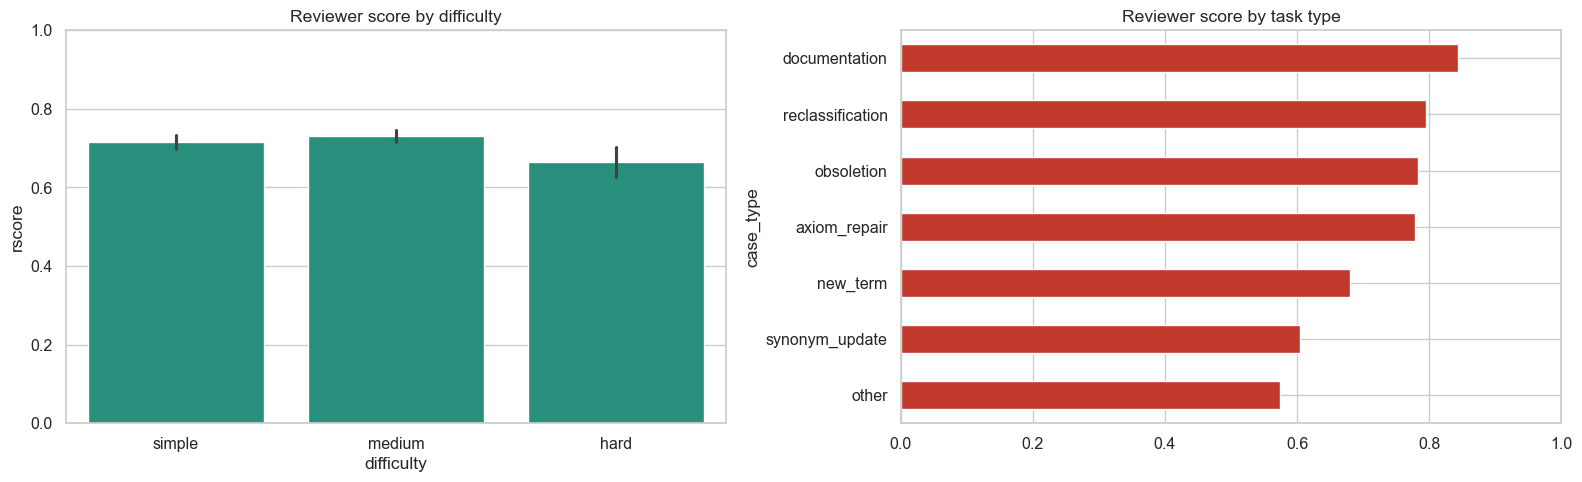

In [12]:
focus=[a for a in ['std_claude_op47','std_claude_son45','std_claude_hai45',
                   'std_codex_g55','std_opencode_g55'] if a in std.agent.unique()]
for by,cap in [('case_type','task type'),('difficulty','difficulty'),('ontology','ontology')]:
    piv=std.pivot_table(values='rscore',index=by,columns='agent',aggfunc='mean')[focus]
    if by=='difficulty': piv=piv.reindex(['simple','medium','hard'])
    show(piv.reset_index(), grad=focus, fmt={c:'{:.3f}' for c in focus},
         hide_index=True, caption=f'Mean reviewer score by {cap} × model tier')
fig,ax=plt.subplots(1,2,figsize=(16,5))
sns.barplot(data=std,x='difficulty',y='rscore',order=['simple','medium','hard'],
            errorbar='se',ax=ax[0],color='#16a085'); ax[0].set_ylim(0,1)
ax[0].set_title('Reviewer score by difficulty')
std.groupby('case_type')['rscore'].mean().sort_values().plot.barh(ax=ax[1],color='#c0392b')
ax[1].set_xlim(0,1); ax[1].set_title('Reviewer score by task type')
plt.tight_layout(); plt.savefig('analysis/notebooks/fig_pp_slices.png',dpi=150); plt.show()


### Q6 · What do agents get wrong? (failure-mode taxonomy)

failure_mode,count
missed_requirement,1235
over_editing,1109
under_editing,1052
wrong_pattern,632
scope_creep,284
wrong_term,125
instruction_violation,76
syntax_error,75
no_changes,16
missing_metadata,10


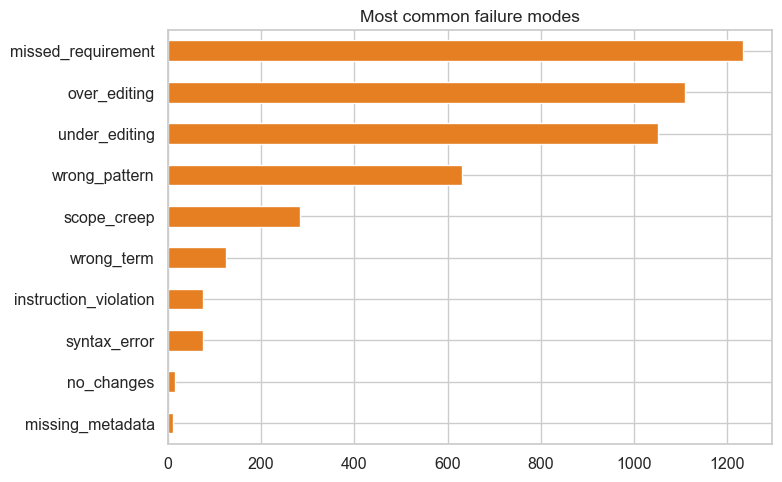

In [13]:
fm=failure_mode_counts(reviews[reviews.outcome.isin(['failure','partial_success'])])
if fm is not None:
    show(fm.head(12).rename_axis('failure_mode').reset_index(name='count'),
         hide_index=True, caption='Most common failure modes (non-success reviews)')
    fig,ax=plt.subplots(figsize=(8,5)); fm.head(10).plot.barh(ax=ax,color='#e67e22')
    ax.invert_yaxis(); ax.set_title('Most common failure modes')
    plt.tight_layout(); plt.savefig('analysis/notebooks/fig_pp_failuremodes.png',dpi=150); plt.show()


## 7. Discussion & limitations

**Findings (exploratory).**
- **Model dominates.** Within a fixed harness the model tier is the
  largest, most robust effect (Q1: Opus > Sonnet > Haiku).
- **Harness is largely interchangeable** at a given model tier (Q3).
- **Difficulty / task type structure performance** (Q5): all agents
  degrade on hard, open-ended tasks.
- The reviewer score is **stable** (§4) and a better basis than F1
  (§3: weak correlation, large within-verdict F1 spread).

**Limitations.**
- Reviewers are themselves LLM agents; IAA (§4) bounds confidence.
  Mondo agreement is weak — treat Mondo-specific numbers cautiously.
- p-values are exploratory, **not** multiplicity-corrected; confirmatory
  work should pre-register the key contrasts (Q1, Q3).
- ~half of mined real PRs are unsuitable as single-gold targets (§1) —
  a result in itself and the reason this analysis is reviewer-anchored.

### Coverage caveat — structural no-coverage cases

Over the fillable universe all six target agents are ~fully covered;
four (agent, case) slots are accepted as measured outcomes (agent
deterministically produces no committed edit, or the eval-base step
fails for every agent): cell #3163 (all agents), cell #3559 / Opus,
go #19185, uberon #3591 — excluded by the same logic as
`case_quality: poor`.